<a href="https://colab.research.google.com/github/kuretaru/topo-ml-spin-phases/blob/develop/src/main_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Investigating Phase Transitions with TDA


## 1. Imports & Setup

In [8]:
!wget https://raw.githubusercontent.com/kuretaru/topo-ml-spin-phases/main/src/simulation.py
!wget https://raw.githubusercontent.com/kuretaru/topo-ml-spin-phases/main/src/tda_feature.py

--2025-12-15 18:18:37--  https://raw.githubusercontent.com/kuretaru/topo-ml-spin-phases/main/src/simulation.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.109.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2214 (2.2K) [text/plain]
Saving to: ‘simulation.py.1’

simulation.py.1     100%[===================>]   2.16K  --.-KB/s    in 0s      

2025-12-15 18:18:37 (26.1 MB/s) - ‘simulation.py.1’ saved [2214/2214]

--2025-12-15 18:18:37--  https://raw.githubusercontent.com/kuretaru/topo-ml-spin-phases/main/src/tda_feature.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.110.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1075 (1.0K

In [2]:
!pip install gudhi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 21.8 MB/s eta 0:00:00


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Custom modules
from tda_feature import get_entropy
from simulation import create_and_save_dataset, simulate_ising

/usr/local/lib/python3.12/dist-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


## 2. Data Generation
We generate 50 samples of Ordered phase (T=1.0) and 50 of Disordered phase (T=3.5).

In [4]:
# Generate data (Only run once!)
# L=30 is fast and enough for TDA. Steps=500_000 ensures equilibrium.
create_and_save_dataset(30, 500_000)

Generating 50 Cold samples...
Generating 50 Hot samples...
Saving data to 'data_x.npy' and 'data_y.npy'...
Done! Dataset ready.


## 3. Feature Engineering (TDA)
We calculate Persistent Entropy for $H_1$ (loops) for each lattice.

In [5]:
X = np.load('data_x.npy')
y = np.load('data_y.npy')

print("Calculating topological entropy...")
feature_list = [get_entropy(lattice) for lattice in X]

# Convert to shape (100, 1) for Sklearn
X_features = np.array(feature_list).reshape(-1, 1)

print(f"Feature Matrix Shape: {X_features.shape}")
print(f"Sample Entropy (Cold): {X_features[0][0]}")
print(f"Sample Entropy (Hot):  {X_features[-1][0]}")

Calculating topological entropy...
Feature Matrix Shape: (100, 1)
Sample Entropy (Cold): 0.0
Sample Entropy (Hot):  2.3025850929940455


## 4. Machine Learning Classification

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X_features, y, test_size=0.2, random_state=42
)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print(f"Model Accuracy: {acc * 100:.2f}%")
print(classification_report(y_test, y_pred, target_names=["Ordered", "Disordered"]))

Model Accuracy: 100.00%
              precision    recall  f1-score   support

     Ordered       1.00      1.00      1.00        12
  Disordered       1.00      1.00      1.00         8

    accuracy                           1.00        20
   macro avg       1.00      1.00      1.00        20
weighted avg       1.00      1.00      1.00        20



## 5. Visualization

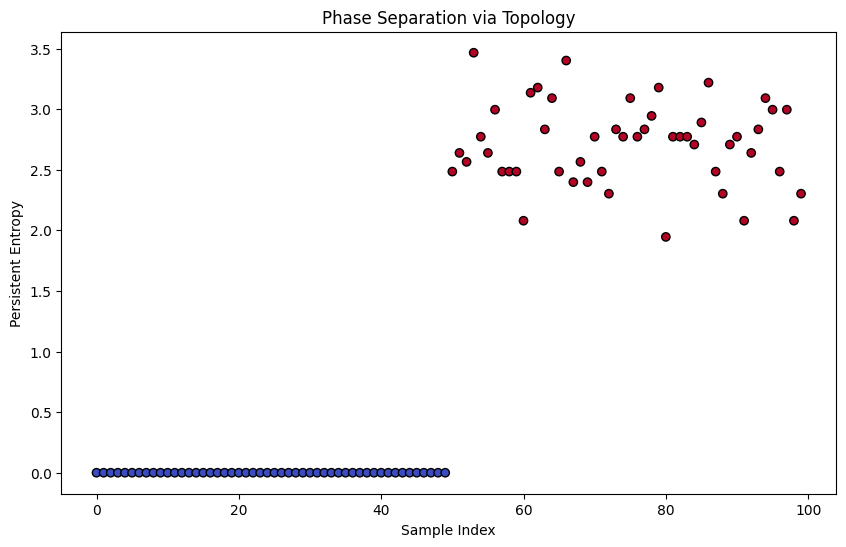

In [7]:
plt.figure(figsize=(10, 6))
plt.scatter(range(len(X_features)), X_features, c=y, cmap='coolwarm', edgecolor='k')
plt.xlabel("Sample Index")
plt.ylabel("Persistent Entropy")
plt.title("Phase Separation via Topology")
plt.show()